In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
import scipy.linalg
warnings.filterwarnings("ignore")

os.environ['R_HOME'] = '/root/miniconda3/envs/njy1/lib/R'

In [2]:
from utils import mclust_R

In [3]:
import sklearn.neighbors
import scipy.sparse as sp

def Cal_Spatial_Net(adata, rad_cutoff=None, k_cutoff=None,
                    max_neigh=50, model='Radius', verbose=True):
    assert (model in ['Radius', 'KNN'])
    if verbose:
        print('------Calculating spatial graph...')
    coor = pd.DataFrame(adata.obsm['spatial'])
    coor.index = adata.obs.index
    coor.columns = ['imagerow', 'imagecol']

    nbrs = sklearn.neighbors.NearestNeighbors(
        n_neighbors=max_neigh + 1, algorithm='ball_tree').fit(coor)
    distances, indices = nbrs.kneighbors(coor)
    if model == 'KNN':
        indices = indices[:, 1:k_cutoff + 1]
        distances = distances[:, 1:k_cutoff + 1]
    if model == 'Radius':
        indices = indices[:, 1:]
        distances = distances[:, 1:]

    KNN_list = []
    for it in range(indices.shape[0]):
        KNN_list.append(pd.DataFrame(zip([it] * indices.shape[1], indices[it, :], distances[it, :])))
    KNN_df = pd.concat(KNN_list)
    KNN_df.columns = ['Cell1', 'Cell2', 'Distance']

    Spatial_Net = KNN_df.copy()
    if model == 'Radius':
        Spatial_Net = KNN_df.loc[KNN_df['Distance'] < rad_cutoff,]
    id_cell_trans = dict(zip(range(coor.shape[0]), np.array(coor.index), ))
    Spatial_Net['Cell1'] = Spatial_Net['Cell1'].map(id_cell_trans)
    Spatial_Net['Cell2'] = Spatial_Net['Cell2'].map(id_cell_trans)
    # self_loops = pd.DataFrame(zip(Spatial_Net['Cell1'].unique(), Spatial_Net['Cell1'].unique(),
    #                  [0] * len((Spatial_Net['Cell1'].unique())))) ###add self loops
    # self_loops.columns = ['Cell1', 'Cell2', 'Distance']
    # Spatial_Net = pd.concat([Spatial_Net, self_loops], axis=0)

    if verbose:
        print('The graph contains %d edges, %d cells.' % (Spatial_Net.shape[0], adata.n_obs))
        print('%.4f neighbors per cell on average.' % (Spatial_Net.shape[0] / adata.n_obs))
    adata.uns['Spatial_Net'] = Spatial_Net

    #########
    X = pd.DataFrame(adata.X.toarray()[:, ], index=adata.obs.index, columns=adata.var.index)
    cells = np.array(X.index)
    cells_id_tran = dict(zip(cells, range(cells.shape[0])))
    if 'Spatial_Net' not in adata.uns.keys():
        raise ValueError("Spatial_Net is not existed! Run Cal_Spatial_Net first!")
        
    Spatial_Net = adata.uns['Spatial_Net']
    G_df = Spatial_Net.copy()
    G_df['Cell1'] = G_df['Cell1'].map(cells_id_tran)
    G_df['Cell2'] = G_df['Cell2'].map(cells_id_tran)
    G = sp.coo_matrix((np.ones(G_df.shape[0]), (G_df['Cell1'], G_df['Cell2'])), shape=(adata.n_obs, adata.n_obs))
    G = G + sp.eye(G.shape[0])  # self-loop
    adata.uns['adj'] = G

In [4]:
Batch_list = []
adj_list = []
section_ids = ['E9.5_E1S1.MOSTA', 'E10.5_E2S1.MOSTA', 'E11.5_E1S1.MOSTA']
print(section_ids)

for section_id in section_ids:
    print(section_id)
    input_dir = os.path.join('../../../Data/Mouse_Embryo')
    adata = sc.read_h5ad(os.path.join(input_dir, section_id + '.h5ad'))
    adata.var_names_make_unique(join="++")

    # read the annotation
    # Ann_df = pd.read_csv(os.path.join(input_dir, 'manual_annotations.txt'), sep='\t', header=None, index_col=0)
    # Ann_df.columns = ['Ground Truth']
    # Ann_df[Ann_df.isna()] = "unknown"
    # adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth'].astype('category')
    
    # make spot name unique
    adata.obs_names = [x+'_'+section_id for x in adata.obs_names]
    
    # Constructing the spatial network
    Cal_Spatial_Net(adata, rad_cutoff=2) # the spatial network are saved in adata.uns[‘adj’]
    # STAligner.Stats_Spatial_Net(adata) # plot the number of spatial neighbors
    
    # Normalization
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
    adata = adata[:, adata.var['highly_variable']]

    adj_list.append(adata.uns['adj'])
    Batch_list.append(adata)

['E9.5_E1S1.MOSTA', 'E10.5_E2S1.MOSTA', 'E11.5_E1S1.MOSTA']
E9.5_E1S1.MOSTA
------Calculating spatial graph...
The graph contains 46462 edges, 5913 cells.
7.8576 neighbors per cell on average.
E10.5_E2S1.MOSTA
------Calculating spatial graph...
The graph contains 66796 edges, 8494 cells.
7.8639 neighbors per cell on average.
E11.5_E1S1.MOSTA
------Calculating spatial graph...
The graph contains 332894 edges, 30124 cells.
11.0508 neighbors per cell on average.


In [5]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
# adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (44531, 1193)


In [6]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(section_ids)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['Spatial_Net'] = np.nonzero(adj_concat)

In [7]:
import torch
from tqdm import tqdm
from STAGATE import STAGATE

import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def train_STAGATE(adata, hidden_dims=[512, 30], n_epochs=1000, lr=0.001, key_added='STAGATE',
                  gradient_clipping=5., weight_decay=0.0001, verbose=True,
                  random_seed=0, save_loss=False, save_reconstrction=False,
                  device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')):
    # seed_everything()
    seed = random_seed
    import random
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

    adata.X = sp.csr_matrix(adata.X)

    if 'highly_variable' in adata.var.columns:
        adata_Vars = adata[:, adata.var['highly_variable']]
    else:
        adata_Vars = adata

    if verbose:
        print('Size of Input: ', adata_Vars.shape)
    if 'Spatial_Net' not in adata.uns.keys():
        raise ValueError("Spatial_Net is not existed! Run Cal_Spatial_Net first!")
    
    edgeList = adata.uns['Spatial_Net']
    data = Data(edge_index=torch.LongTensor(np.array([edgeList[0], edgeList[1]])),
                prune_edge_index=torch.LongTensor(np.array([])),
                x=torch.FloatTensor(adata.X.todense()))
    data = data.to(device)

    # data = Transfer_pytorch_Data(adata_Vars)

    model = STAGATE(hidden_dims=[data.x.shape[1]] + hidden_dims).to(device)
    data = data.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # loss_list = []
    for epoch in tqdm(range(1, n_epochs + 1)):
        model.train()
        optimizer.zero_grad()
        z, out = model(data.x, data.edge_index)
        loss = F.mse_loss(data.x, out)  # F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        # loss_list.append(loss)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
        optimizer.step()

    model.eval()
    z, out = model(data.x, data.edge_index)

    STAGATE_rep = z.to('cpu').detach().numpy()
    adata.obsm[key_added] = STAGATE_rep

    if save_loss:
        adata.uns['STAGATE_loss'] = loss
    if save_reconstrction:
        ReX = out.to('cpu').detach().numpy()
        ReX[ReX < 0] = 0
        adata.layers['STAGATE_ReX'] = ReX

    return adata

In [9]:
device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
adata_concat = train_STAGATE(adata_concat, n_epochs=1000, device=device)

Size of Input:  (44531, 1193)


100%|██████████| 1000/1000 [00:42<00:00, 23.48it/s]


In [10]:
# sc.pp.neighbors(adata, use_rep='STAGATE')
# sc.tl.umap(adata)

In [11]:
adata_concat = mclust_R(adata_concat, used_obsm='STAGATE', num_cluster=20)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [12]:
# adata_concat = sc.read_h5ad('adata_STAGATE_MOE.h5ad')

In [13]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [14]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")

total ARI:0.2579616909489512
E9.5_E1S1.MOSTA ARI:0.0426834175573884
E10.5_E2S1.MOSTA ARI:0.11652207032987688
E11.5_E1S1.MOSTA ARI:0.37917591395616285


In [15]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} NMI:{NMI}")

total NMI:0.5444761103021489
E9.5_E1S1.MOSTA NMI:0.19276397573387902
E10.5_E2S1.MOSTA NMI:0.38711498818357587
E11.5_E1S1.MOSTA NMI:0.6196477154374112


In [16]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{HOM}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} HOM:{HOM}")

total NMI:0.5399584141037798
E9.5_E1S1.MOSTA HOM:0.11276698478744954
E10.5_E2S1.MOSTA HOM:0.2733288104382291
E11.5_E1S1.MOSTA HOM:0.6173138039046526


In [17]:
import scib

sc.pp.neighbors(adata_concat, use_rep="STAGATE")
scib.me.graph_connectivity(adata_concat, label_key="annotation")

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() inste

0.7965408911194077

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


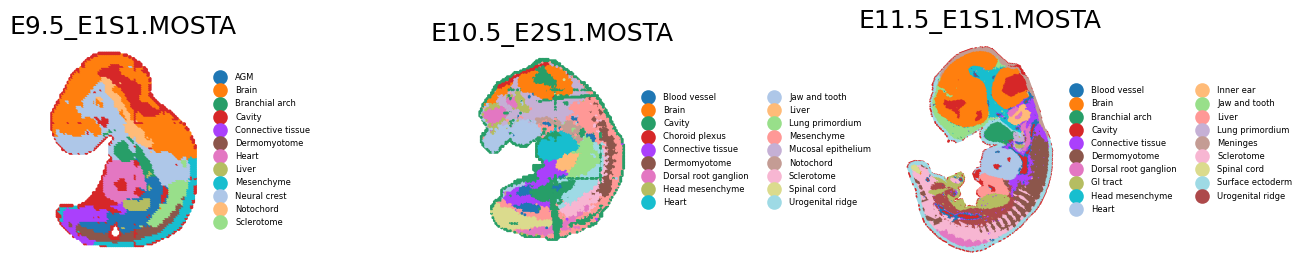

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for slice_id, slice_name in enumerate(section_ids):
    adata_tmp = adata_concat[adata_concat.obs['batch_name'] == section_ids[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['annotation'], title=[''],
                  legend_loc="right margin", legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


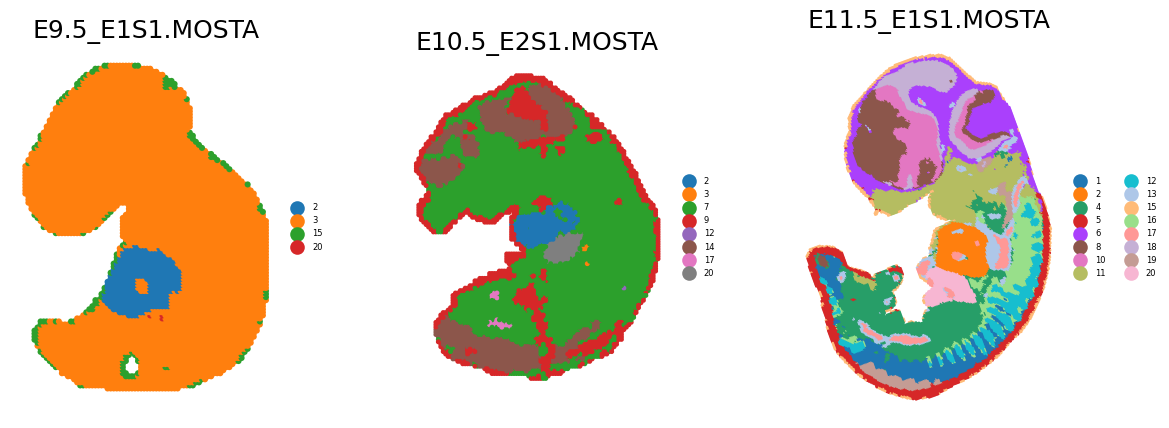

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for slice_id, slice_name in enumerate(section_ids):
    adata_tmp = adata_concat[adata_concat.obs['batch_name'] == section_ids[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc="right margin", legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()